In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [89]:
df.shape

(7043, 33)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [91]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


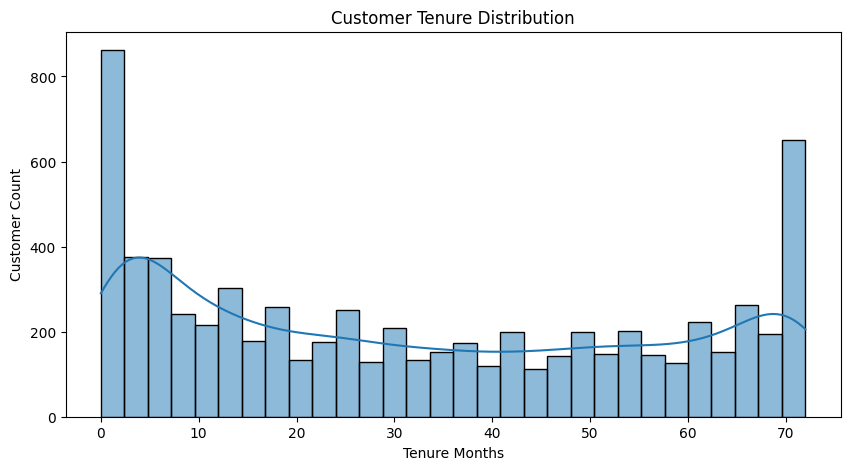

In [92]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Customer Tenure Distribution')
plt.show()

In [93]:
print("max "+str(df['Tenure Months'].max()))
print("min "+str(df['Tenure Months'].min()))

max 72
min 0


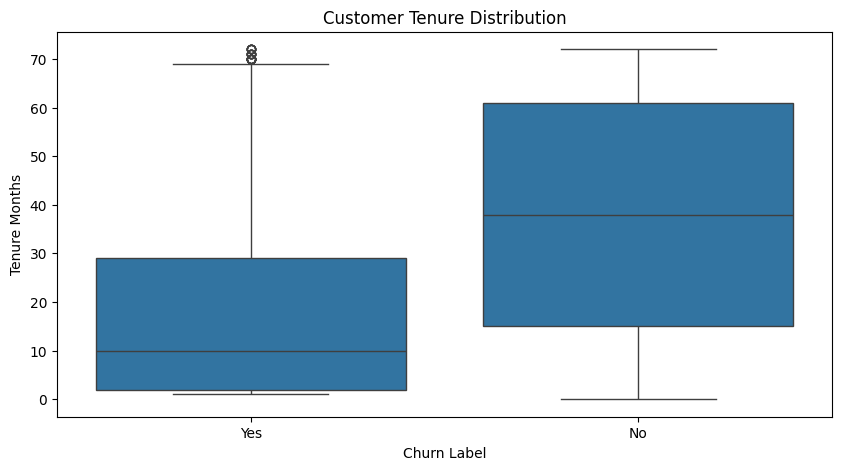

In [94]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn Label',y='Tenure Months',data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Customer Tenure Distribution')
plt.show()

In [95]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

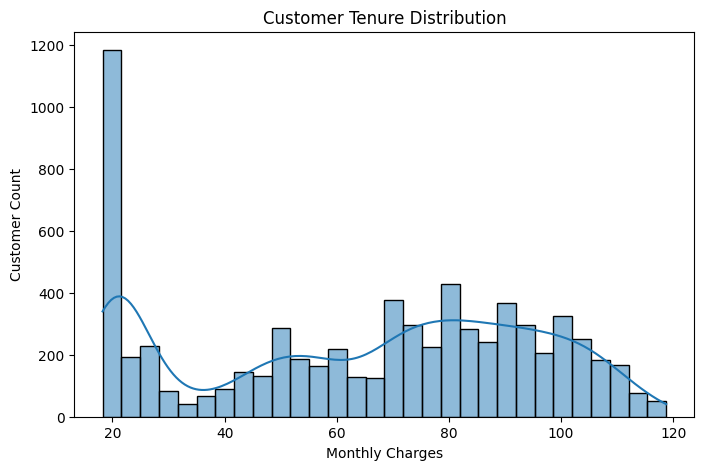

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Customer Tenure Distribution')
plt.show()

In [97]:
df['Monthly Charges'].max()

118.75

In [98]:
df['Monthly Charges'].min()

18.25

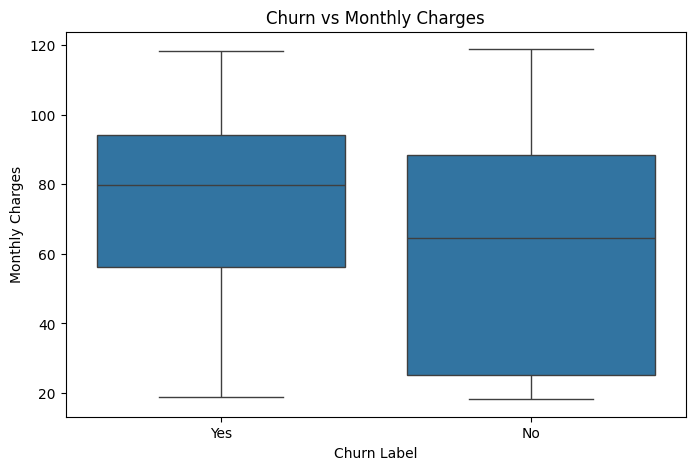

In [99]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y='Monthly Charges',data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')
plt.show()

In [100]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [101]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [102]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [103]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

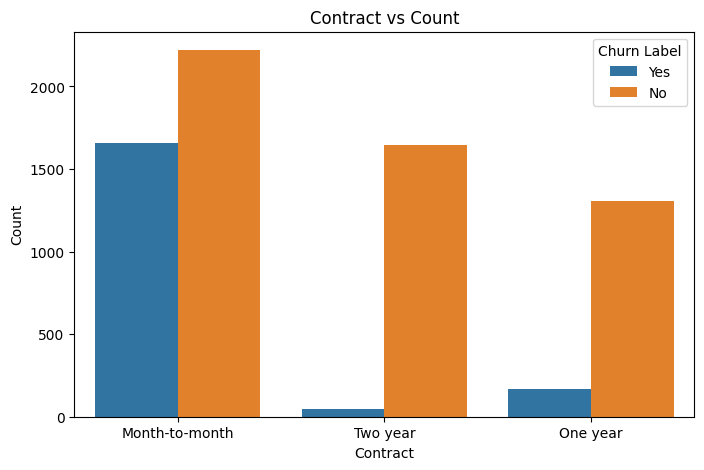

In [104]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label',data=df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs Count')
plt.show()

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [106]:
X=df.drop(['CustomerID', 'Churn Label', 'Churn Value', 'Churn Reason', 'Churn Score'],axis=1)
Y=df['Churn Value']

In [107]:
print(X)

      Count        Country       State          City  Zip Code  \
0         1  United States  California   Los Angeles     90003   
1         1  United States  California   Los Angeles     90005   
2         1  United States  California   Los Angeles     90006   
3         1  United States  California   Los Angeles     90010   
4         1  United States  California   Los Angeles     90015   
...     ...            ...         ...           ...       ...   
7038      1  United States  California       Landers     92285   
7039      1  United States  California      Adelanto     92301   
7040      1  United States  California         Amboy     92304   
7041      1  United States  California  Angelus Oaks     92305   
7042      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender Senior Citizen  \
0     33.964131, -118.272783  33.964131 -118.272783    Male             No   
1      34.059281, -118.30742  34.059281 -118.307420

In [108]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


In [109]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV,CustomerID_0003-MKNFE,...,Churn Reason_Lack of self-service on Website,Churn Reason_Limited range of services,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction
0,1,90003,33.964131,-118.272783,2,53.85,1,86,3239,False,...,False,False,False,False,False,False,False,False,False,False
1,1,90005,34.059281,-118.307420,2,70.70,1,67,2701,False,...,False,False,False,True,False,False,False,False,False,False
2,1,90006,34.048013,-118.293953,8,99.65,1,86,5372,False,...,False,False,False,True,False,False,False,False,False,False
3,1,90010,34.062125,-118.315709,28,104.80,1,84,5003,False,...,False,False,False,True,False,False,False,False,False,False
4,1,90015,34.039224,-118.266293,49,103.70,1,89,5340,False,...,False,False,False,False,False,False,False,False,False,False


In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [111]:
X_train.shape


(5634, 28)

In [112]:
X_test.shape

(1409, 28)

In [113]:
Y_train.shape

(5634,)

In [114]:
Y_test.shape

(1409,)

In [115]:
from sklearn.ensemble import RandomForestClassifier

In [116]:
rf_model= RandomForestClassifier(n_estimators=300, random_state=42)


In [117]:
X_train['Total Charges'] = pd.to_numeric(X_train['Total Charges'], errors='coerce')
X_train['Total Charges'] = X_train['Total Charges'].fillna(0)

categorical_cols = X_train.select_dtypes(include=['object']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

rf_model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [118]:

X_test_temp = X_test.copy()
X_test_temp['Total Charges'] = pd.to_numeric(X_test_temp['Total Charges'], errors='coerce')
X_test_temp['Total Charges'] = X_test_temp['Total Charges'].fillna(0)

categorical_cols_test = X_test_temp.select_dtypes(include=['object']).columns
X_test_temp = pd.get_dummies(X_test_temp, columns=categorical_cols_test, drop_first=True)
X_train_columns_for_predict = X_train.columns
X_test_temp = X_test_temp.reindex(columns=X_train_columns_for_predict, fill_value=0)

y_pred = rf_model.predict(X_test_temp)

In [119]:
print(y_pred)

[0 0 0 ... 1 0 1]


### Model Evaluation on Test Set

In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X_test_processed = X_test.copy()
X_test_processed['Total Charges'] = pd.to_numeric(X_test_processed['Total Charges'], errors='coerce')
X_test_processed['Total Charges'] = X_test_processed['Total Charges'].fillna(0)
categorical_cols_test = X_test_processed.select_dtypes(include=['object']).columns
X_test_processed = pd.get_dummies(X_test_processed, columns=categorical_cols_test, drop_first=True)
X_train_columns = X_train.columns
X_test_processed = X_test_processed.reindex(columns=X_train_columns, fill_value=0)
Y_pred = rf_model.predict(X_test_processed)
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 0.8013
Precision: 0.7190
Recall: 0.4925
F1-Score: 0.5846

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,932,77
Actual Churn,203,197



Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1009
           1       0.72      0.49      0.58       400

    accuracy                           0.80      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [121]:
X_test_processed = X_test_processed.reindex(columns=X_train_columns, fill_value=0)

In [122]:
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(Y_train), y=Y_train)
class_weights = dict(zip(np.unique(Y_train), class_weights_array))
print("Class Weights:")
print(class_weights_array)

Class Weights:
[0.67635054 1.91763104]


In [123]:
rf_balanced = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, Y_train)
y_pred_balanced = rf_balanced.predict(X_test_processed)
accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)
cm_balanced = confusion_matrix(Y_test, y_pred_balanced)
cr_balanced = classification_report(Y_test, y_pred_balanced)
print("Balanced Random Forest Results:")
print(f"Balanced Accuracy: {accuracy_balanced}")
print(accuracy_balanced,cm_balanced)
print(classification_report(Y_test, y_pred_balanced))

Balanced Random Forest Results:
Balanced Accuracy: 0.8055358410220014
0.8055358410220014 [[911  98]
 [176 224]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1009
           1       0.70      0.56      0.62       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



HyperParameter Tuning

In [124]:
rf_tuned = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10, min_samples_split=15)
rf_tuned.fit(X_train, Y_train)
y_pred_tuned = rf_tuned.predict(X_test_processed)
print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1009
           1       0.52      0.82      0.63       400

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.74      1409



###Finding best fit in Hyperparameter Tuning with GridSearchCV for F1-score

In [127]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'n_estimators': [100, 200, 300]
}
rf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')
scorer = make_scorer(f1_score, pos_label=1)
grid_search = GridSearchCV(estimator=rf_grid, param_grid=param_grid, cv=5, scoring=scorer, verbose=3, n_jobs=-1)
grid_search.fit(X_train, Y_train)
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score for churn class: {grid_search.best_score_:.4f}")
best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best parameters found: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
Best F1-score for churn class: 0.6451


Testing the Metrics

In [131]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_best = best_rf_model.predict(X_test_processed)
print("Classification Report for Best Tuned Model:")
print(classification_report(Y_test, y_pred_best))
conf_matrix_best = confusion_matrix(Y_test, y_pred_best)
print("\nConfusion Matrix for Best Tuned Model:")
display(pd.DataFrame(conf_matrix_best, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))


Classification Report for Best Tuned Model:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1009
           1       0.55      0.78      0.65       400

    accuracy                           0.76      1409
   macro avg       0.73      0.77      0.73      1409
weighted avg       0.80      0.76      0.77      1409


Confusion Matrix for Best Tuned Model:


,Predicted No Churn,Predicted Churn
Actual No Churn,758,251
Actual Churn,87,313


Approach 3: Feature Importance analysis

In [133]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
})
feature_importances = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importances)

                           Feature  Importance
4                    Tenure Months    0.079217
6                    Total Charges    0.067904
2809             Contract_Two year    0.061539
2794  Internet Service_Fiber optic    0.047522
5                  Monthly Charges    0.040671
...                            ...         ...
494           City_Knights Landing    0.000000
1034                    City_Trona    0.000000
610                  City_Mcarthur    0.000000
971              City_Squaw Valley    0.000000
0                            Count    0.000000

[2814 rows x 2 columns]


###Plotting 15 most important features for Churn Prediction

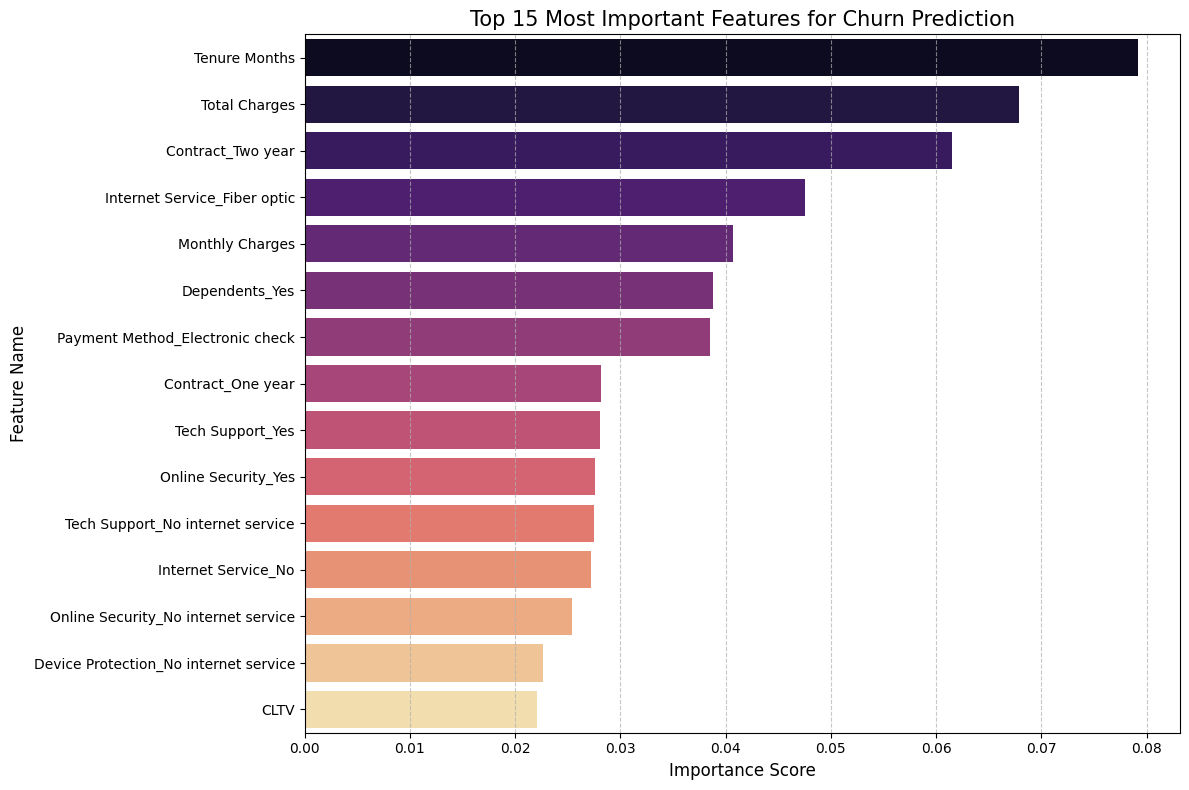

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
top_15_features = feature_importances.head(15)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, hue='Feature', palette='magma', legend=False)
plt.title('Top 15 Most Important Features for Churn Prediction', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Saving the trained Model for feature use

In [135]:
import joblib
model_filename = 'best_churn_model.joblib'
joblib.dump(best_rf_model, model_filename)
print(f"Model successfully saved as: {model_filename}")

Model successfully saved as: best_churn_model.joblib


###Plotting the roc_curve and checking the auc_score for the model

In [136]:
from sklearn.metrics import roc_curve, roc_auc_score

In [137]:
y_prob = best_rf_model.predict_proba(X_test_processed)

In [141]:
churn_prob = y_prob[:, 1]
fpr,tpr,threshold=roc_curve(Y_test,churn_prob)
auc_score = roc_auc_score(Y_test, churn_prob)
print(auc_score)
print(fpr)
print(tpr)
print(threshold)

0.8452576808721506
[0.00000000e+00 0.00000000e+00 0.00000000e+00 9.91080278e-04
 9.91080278e-04 1.98216056e-03 1.98216056e-03 2.97324083e-03
 2.97324083e-03 3.96432111e-03 3.96432111e-03 4.95540139e-03
 4.95540139e-03 5.94648167e-03 5.94648167e-03 7.92864222e-03
 7.92864222e-03 8.91972250e-03 8.91972250e-03 1.18929633e-02
 1.18929633e-02 1.38751239e-02 1.38751239e-02 1.48662042e-02
 1.48662042e-02 1.58572844e-02 1.58572844e-02 1.68483647e-02
 1.68483647e-02 1.78394450e-02 1.78394450e-02 1.88305253e-02
 1.88305253e-02 1.98216056e-02 1.98216056e-02 2.08126858e-02
 2.08126858e-02 2.37859267e-02 2.37859267e-02 2.47770069e-02
 2.47770069e-02 2.67591675e-02 2.67591675e-02 2.77502478e-02
 2.77502478e-02 2.97324083e-02 2.97324083e-02 3.07234886e-02
 3.07234886e-02 3.46878097e-02 3.46878097e-02 3.56788900e-02
 3.56788900e-02 3.76610505e-02 3.76610505e-02 3.86521308e-02
 3.86521308e-02 3.96432111e-02 3.96432111e-02 4.16253717e-02
 4.16253717e-02 4.26164519e-02 4.26164519e-02 4.55896928e-02
 4.55

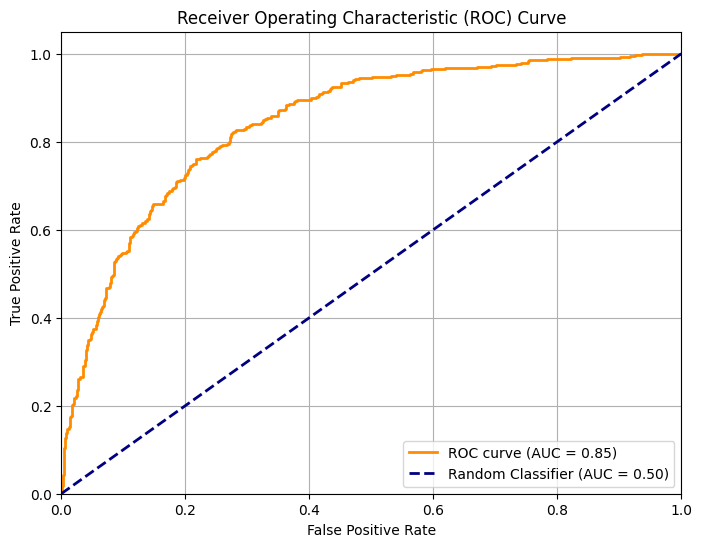

In [140]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Customer Segmentation

In [142]:
segmentation_data = pd.DataFrame({
    'Tenure Months': df.loc[X_test_processed.index, 'Tenure Months'],
    'Total Charges': pd.to_numeric(df.loc[X_test_processed.index, 'Total Charges'], errors='coerce'),
    'Contract': df.loc[X_test_processed.index, 'Contract'],
    'Monthly Charges': df.loc[X_test_processed.index, 'Monthly Charges'],
    'Churn_Probability': y_prob[:, 1]
})

segmentation_data

,Tenure Months,Total Charges,Contract,Monthly Charges,Churn_Probability
185,15,1269.55,Month-to-month,85.90,0.671390
2715,18,1074.65,Month-to-month,56.80,0.427412
3825,2,40.90,Month-to-month,20.00,0.292214
1807,6,519.15,Month-to-month,84.20,0.746501
132,40,4131.95,Month-to-month,104.80,0.485109
...,...,...,...,...,...
6366,66,6891.45,One year,104.90,0.407097
315,19,1532.45,Month-to-month,86.00,0.661980
2439,2,190.50,Month-to-month,90.35,0.646994
5002,68,7467.50,Two year,110.20,0.258213


Implementation Of kmeans

In [143]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [144]:
segmentation_encoded = pd.get_dummies(segmentation_data, columns=['Contract'], drop_first=True)
scaled_data = scaler.fit_transform(segmentation_encoded)
print(scaled_data[:5])

[[-0.69631406 -0.45048988  0.6691038   1.09219439 -0.50797216 -0.53659499]
 [-0.57429095 -0.53600108 -0.31419848  0.02573193 -0.50797216 -0.53659499]
 [-1.22508089 -0.98955267 -1.55768728 -0.56523207 -0.50797216 -0.53659499]
 [-1.0623834  -0.77972336  0.61166002  1.4205108  -0.50797216 -0.53659499]
 [ 0.32054522  0.80537089  1.30774342  0.27793368 -0.50797216 -0.53659499]]


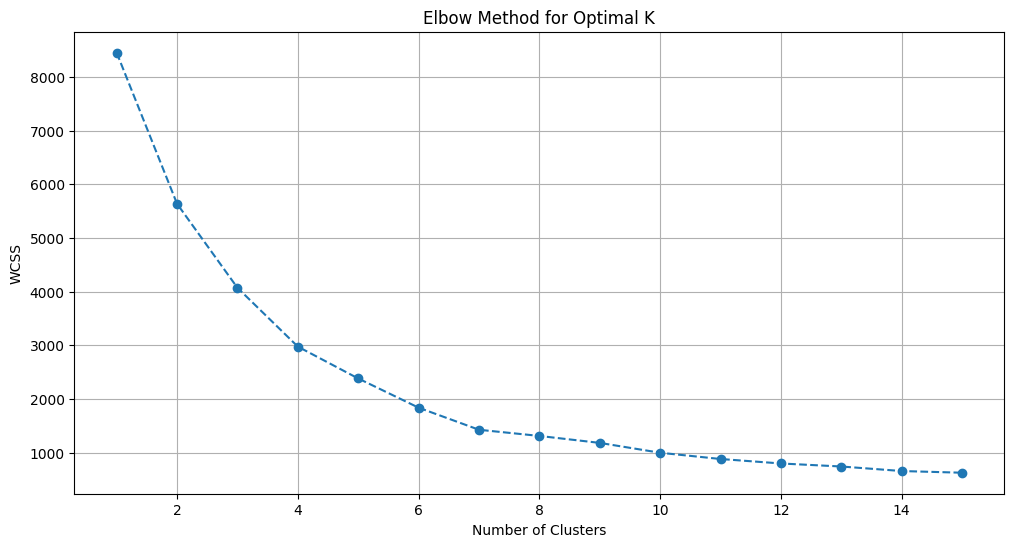

In [145]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss =[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(12,6))
plt.plot(range(1,16),wcss,marker='o',linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [148]:
kmeans = KMeans(n_clusters=6, random_state=42)
segmentation_data['cluster'] = kmeans.fit_predict(scaled_data)

In [149]:
segmentation_data

,Tenure Months,Total Charges,Contract,Monthly Charges,Churn_Probability,cluster
185,15,1269.55,Month-to-month,85.90,0.671390,0
2715,18,1074.65,Month-to-month,56.80,0.427412,5
3825,2,40.90,Month-to-month,20.00,0.292214,5
1807,6,519.15,Month-to-month,84.20,0.746501,0
132,40,4131.95,Month-to-month,104.80,0.485109,2
...,...,...,...,...,...,...
6366,66,6891.45,One year,104.90,0.407097,2
315,19,1532.45,Month-to-month,86.00,0.661980,0
2439,2,190.50,Month-to-month,90.35,0.646994,0
5002,68,7467.50,Two year,110.20,0.258213,4


In [150]:

segmentation_encoded['cluster'] = segmentation_data['cluster']
cluster_summary = segmentation_encoded.groupby('cluster').mean()


In [151]:
cluster_summary

,Tenure Months,Total Charges,Monthly Charges,Churn_Probability,Contract_One year,Contract_Two year
cluster,,,,,,
0,13.195545,1136.863614,83.195545,0.682227,0.000000,0.0
1,46.691176,1261.535662,27.905882,0.106447,0.000000,1.0
2,54.851485,5215.462871,95.148020,0.436348,0.509901,0.0
3,34.860215,1613.135753,45.726882,0.245277,1.000000,0.0
4,66.067039,5964.417318,89.993855,0.229033,0.000000,1.0
5,13.857616,607.476821,39.379139,0.427389,0.000000,0.0


### Customer Segment Definitions

| Cluster | Target Persona Name | Characteristics |
| :--- | :--- | :--- |
| **0** | **Loyal High-Value High-Risk** | High spenders with long tenure; despite contracts, their churn score is creeping up. |
| **1** | **Locked-in Long-Termers** | The 'Gold Standard' customers. Two-year contracts, long tenure, and very low churn risk. |
| **2** | **Mid-Tier Value Mid-Termers** | Stable customers on one-year contracts with moderate monthly spend. |
| **3** | **Critical High-Risk Newcomers** | Most at risk. Recent joins with high monthly charges and the highest churn probability. |
| **4** | **Economical Long-Termers** | Loyal customers who have been with the company a long time but on low-cost plans. |
| **5** | **Month-to-Month Trialists** | New customers on flexible plans; they have low tenure and are still deciding their long-term loyalty. |

In [152]:
cluster_summary={
    0:'Loyal High-Value High-Risk',
    1:'Locked-in Long-Termers',
    2:'Mid-Tier Value Mid-Termers',
    3:'Critical High-Risk Newcomers',
    4:'Economical Long-Termers',
    5:'Month-to-Month Trialists'
}

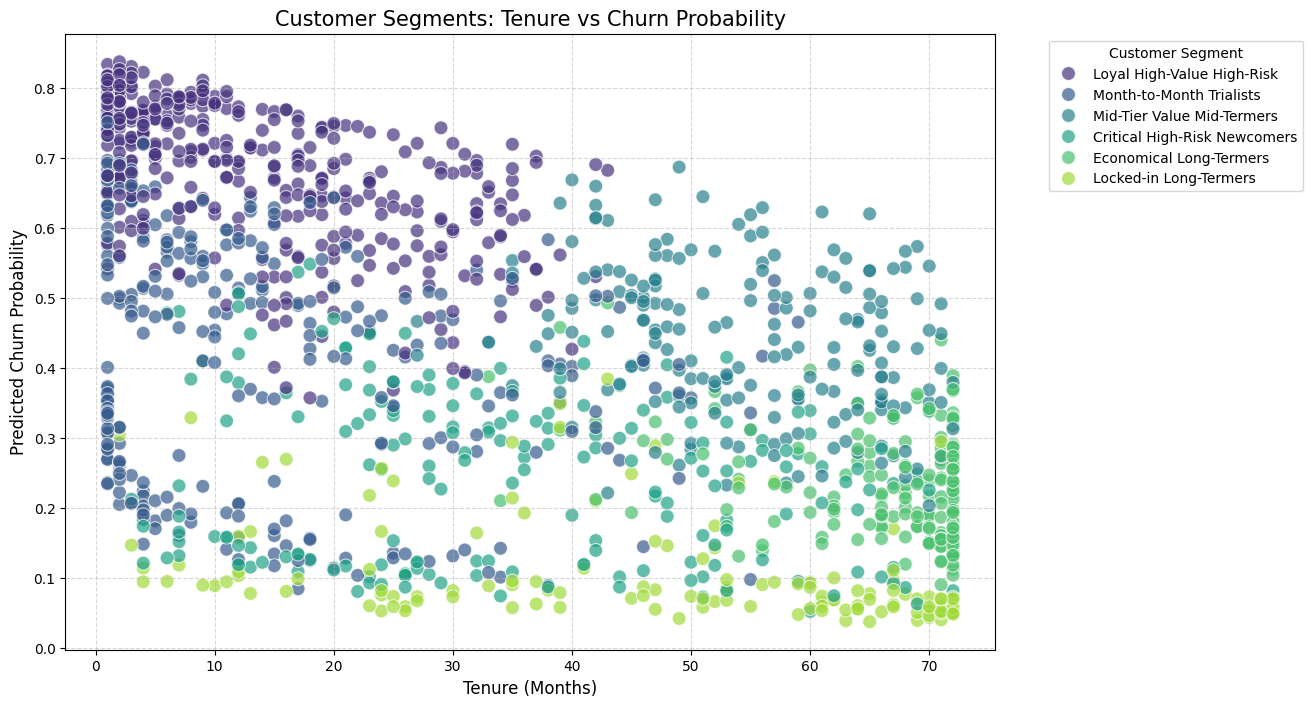

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
segmentation_data['cluster_name'] = segmentation_data['cluster'].map(cluster_summary)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Tenure Months',
    y='Churn_Probability',
    hue='cluster_name',
    data=segmentation_data,
    palette='viridis',
    alpha=0.7,
    s=100
)

plt.title('Customer Segments: Tenure vs Churn Probability', fontsize=15)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Predicted Churn Probability', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Testing on Dummy Data


In [154]:
import pandas as pd
import numpy as np
dummy_customer = {
    'Count': 1,
    'Tenure Months': 1,
    'Monthly Charges': 110.0,
    'Total Charges': 110.0,
    'CLTV': 3000,
    'Contract': 'Month-to-month',
    'Online Security': 'No',
    'Tech Support': 'No',
    'Internet Service': 'Fiber optic',
    'Paperless Billing': 'Yes',
    'Payment Method': 'Electronic check'
}

dummy_df = pd.DataFrame([dummy_customer])
dummy_encoded = pd.get_dummies(dummy_df)
dummy_final = dummy_encoded.reindex(columns=X_train.columns, fill_value=0)

prediction = best_rf_model.predict(dummy_final)[0]
probability = best_rf_model.predict_proba(dummy_final)[0][1]

print(f"Dummy Customer Test:")
print(f"Predicted Class: {'Churn' if prediction == 1 else 'No Churn'}")
print(f"Churn Probability: {probability:.2%}")

Dummy Customer Test:
Predicted Class: Churn
Churn Probability: 70.66%
